# Dimensionality Reduction – Heart Disease Dataset
*PCA, t-SNE, UMAP - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  


In [16]:
# Reproducibility
import os, sys, numpy as np
import pandas as pd
import joblib, umap as u

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.dim_red.plots import plot_cumulative_variance, plot, plot_3d
from imblearn.combine import SMOTEENN

SEED = 42
OUTPUT_DIR = "../outputs/dim_red"

In [2]:
df_prep_bal = joblib.load("../outputs/eda/df_preprocessed_balanced.pkl")
df_prep_bal

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0.163636,1,4.394449,0,0.299065,1,12.964542,0.387744,0.565217,0,0,0.028470,0
1,0.454545,1,3.970292,0,0.205607,1,12.528160,0.576119,0.521739,0,0,0.042705,0
2,0.236364,0,4.158883,1,0.859813,0,12.815841,0.245737,0.434783,1,0,0.064057,0
3,0.181818,1,5.075174,1,0.299065,0,12.618186,0.516206,0.565217,0,0,0.088968,0
4,0.363636,0,7.155591,1,0.299065,0,12.628070,1.000000,0.521739,1,0,0.092527,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,0.101174,0,6.368187,0,0.075979,0,12.010541,0.227812,0.121322,0,0,0.099076,1
304,0.272727,0,7.155591,0,0.259096,0,12.618436,0.453505,0.546076,1,0,0.584392,1
305,0.435440,0,6.989670,0,0.448598,0,12.481274,0.453505,0.447133,1,0,0.138330,1
306,0.823189,1,5.006494,0,0.490314,0,12.505770,0.344733,0.638942,0,0,0.063024,1


In [3]:
# drop target 
df_copy = df_prep_bal.copy()
TARGET_COL = 'DEATH_EVENT'

X = df_copy.drop(columns=[TARGET_COL])
y = df_copy[TARGET_COL]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X = X.drop(columns=cols_to_drop)

## PCA

Explained variance ratio: [0.37015963 0.22591455 0.18584541 0.13150036 0.08658005]
Total variance retained: 0.9999999999999999
Variance kept by first 3 PCs: 0.782


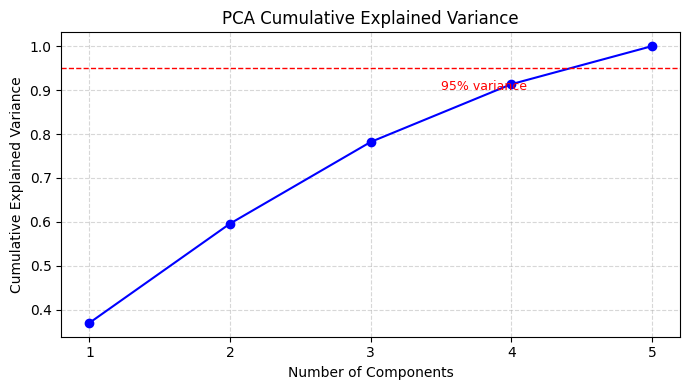

In [ ]:
# PCA with all components
pca_full = PCA()
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
print("Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_cumulative_variance(explained_variance, show_target=0.95)


- The first component explains ~32% of the total variance.
- The first three components together explain ~72% of the variance.
- Around 4 to 5 components are needed to reach 95% variance.

In [5]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PCA_1", "PCA_2", "PCA_3"])
df_pca["DEATH_EVENT"] = y.values

os.makedirs("../outputs/dim_red", exist_ok=True)
joblib.dump(df_pca, "../outputs/dim_red/df_pca.pkl")

['../outputs/dim_red/df_pca.pkl']

In [14]:
plot_3d(X_pca, y, algorithm="PCA", target_name=TARGET_COL)

## t-SNE

In [ ]:
tsne = TSNE(n_components=3)
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2", "tSNE_3"])
df_tsne[TARGET_COL] = y.values

os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(df_tsne, os.path.join(OUTPUT_DIR, 'df_tsne.pkl'))

['../outputs/dim_red\\df_tsne.pkl']

In [25]:
plot_3d(X_tsne, y, algorithm="t-SNE", target_name=TARGET_COL)

## UMAP

In [ ]:
umap = u.UMAP(n_components=3)
X_umap = umap.fit_transform(X)

df_umap = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2", "UMAP_3"])
df_umap[TARGET_COL] = y.values

os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(df_umap, os.path.join(OUTPUT_DIR, 'df_umap.pkl'))

['../outputs/dim_red\\df_umap.pkl']

In [23]:
plot_3d(X_umap, y, algorithm="UMAP", target_name=TARGET_COL)

## MIX
1st component PCA, t-SNE, UMAP

In [26]:
pc1 = X_pca[:, 0]
tsne1 = X_tsne[:, 0]
umap1 = X_umap[:, 0]

X_combined = pd.DataFrame({
    "PCA_1": pc1,
    "tSNE_1": tsne1,
    "UMAP_1": umap1,
})

df_mix = pd.concat(
    [pd.DataFrame(X_combined, columns=X_combined.columns),
     pd.Series(y, name=TARGET_COL)],
    axis=1
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(df_mix, os.path.join(OUTPUT_DIR, 'df_mix.pkl'))

['../outputs/dim_red\\df_mix.pkl']

In [27]:
plot_3d(X_combined, y, algorithm="Mix for the 1st component", target_name=TARGET_COL)